In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [21]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/google_colab/spotify_tracks_dataset_1_2m.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Column Description

> Note: this is the 1.2M-track dataset. It does **not** contain `popularity` or `track_genre` columns (unlike the smaller 114k version). Instead it carries release metadata (`year`, `release_date`, `track_number`, `disc_number`).

- **id**: The Spotify ID for the track
- **name**: Name of the track
- **album**: The album name in which the track appears
- **album_id**: The Spotify ID for the album
- **artists**: The artists' names who performed the track. Stored as a Python-list-style string (e.g. `['Artist A', 'Artist B']`)
- **artist_ids**: The Spotify IDs of the artists, same list-style format as `artists`
- **track_number**: The position of the track within its album/disc
- **disc_number**: The disc the track belongs to (1 for single-disc releases)
- **explicit**: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)
- **danceability**: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable
- **energy**: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale
- **key**: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness**: The overall loudness of a track in decibels (dB)
- **mode**: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0
- **speechiness**: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks
- **acousticness**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic
- **instrumentalness**: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content
- **liveness**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live
- **valence**: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo**: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration
- **duration_ms**: The track length in milliseconds
- **time_signature**: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **year**: The release year of the track
- **release_date**: The full release date of the track (YYYY-MM-DD where available)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1204025 non-null  object 
 1   name              1204022 non-null  object 
 2   album             1204014 non-null  object 
 3   album_id          1204025 non-null  object 
 4   artists           1204025 non-null  object 
 5   artist_ids        1204025 non-null  object 
 6   track_number      1204025 non-null  int64  
 7   disc_number       1204025 non-null  int64  
 8   explicit          1204025 non-null  bool   
 9   danceability      1204025 non-null  float64
 10  energy            1204025 non-null  float64
 11  key               1204025 non-null  int64  
 12  loudness          1204025 non-null  float64
 13  mode              1204025 non-null  int64  
 14  speechiness       1204025 non-null  float64
 15  acousticness      1204025 non-null  float64
 16  

In [23]:
df.describe()

,track_number,disc_number,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,7.656352e+00,1.055906e+00,4.930565e-01,5.095363e-01,5.194151e+00,-1.180870e+01,6.714595e-01,8.438219e-02,4.467511e-01,2.828605e-01,2.015994e-01,4.279866e-01,1.176344e+02,2.488399e+05,3.832494e+00,2.007328e+03
std,5.994977e+00,2.953752e-01,1.896694e-01,2.946839e-01,3.536731e+00,6.982132e+00,4.696827e-01,1.159914e-01,3.852014e-01,3.762844e-01,1.804591e-01,2.704846e-01,3.093705e+01,1.622104e+05,5.611826e-01,1.210117e+01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00
25%,3.000000e+00,1.000000e+00,3.560000e-01,2.520000e-01,2.000000e+00,-1.525400e+01,0.000000e+00,3.510000e-02,3.760000e-02,7.600000e-06,9.680000e-02,1.910000e-01,9.405400e+01,1.740900e+05,4.000000e+00,2.002000e+03
50%,7.000000e+00,1.000000e+00,5.010000e-01,5.240000e-01,5.000000e+00,-9.791000e+00,1.000000e+00,4.460000e-02,3.890000e-01,8.080000e-03,1.250000e-01,4.030000e-01,1.167260e+02,2.243390e+05,4.000000e+00,2.009000e+03
75%,1.000000e+01,1.000000e+00,6.330000e-01,7.660000e-01,8.000000e+00,-6.717000e+00,1.000000e+00,7.230000e-02,8.610000e-01,7.190000e-01,2.450000e-01,6.440000e-01,1.370460e+02,2.858400e+05,4.000000e+00,2.015000e+03
max,5.000000e+01,1.300000e+01,1.000000e+00,1.000000e+00,1.100000e+01,7.234000e+00,1.000000e+00,9.690000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.489340e+02,6.061090e+06,5.000000e+00,2.020000e+03


In [24]:
df.head()

,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


In [25]:
df.shape

(1204025, 24)

In [26]:
df.columns

Index(['id', 'name', 'album', 'album_id', 'artists', 'artist_ids',
       'track_number', 'disc_number', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'time_signature', 'year', 'release_date'],
      dtype='object')

In [27]:
df.dtypes

,0
id,object
name,object
album,object
album_id,object
artists,object
artist_ids,object
track_number,int64
disc_number,int64
explicit,bool
danceability,float64


In [28]:
# data = data.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["artists", "name"])
print("tracks: %d" % len(df))

tracks: 1204022


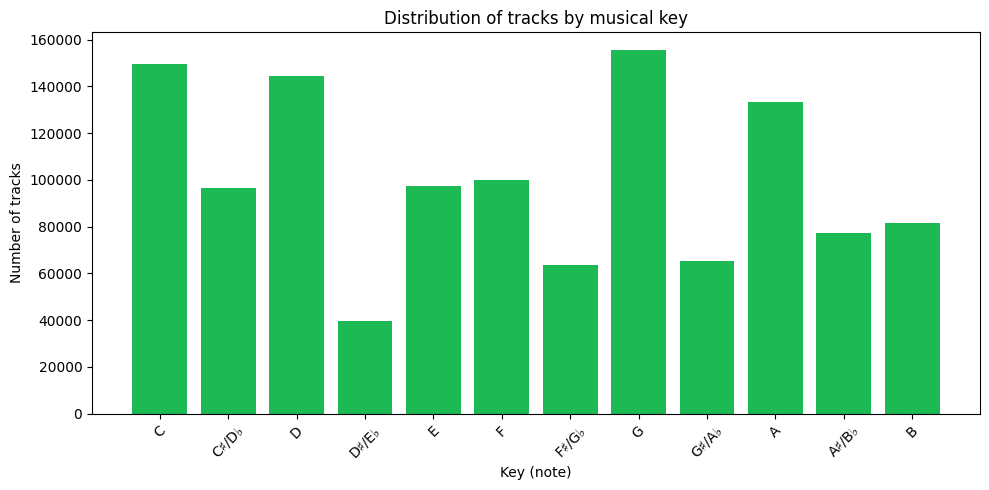

In [29]:
# Pitch class -> note name (index 0..11), per the column description
notes = ['C', 'C♯/D♭', 'D', 'D♯/E♭', 'E', 'F',
         'F♯/G♭', 'G', 'G♯/A♭', 'A', 'A♯/B♭', 'B']

# Count tracks per key, ordered 0..11; drop -1 ("no key detected")
counts = df["key"].value_counts().sort_index()
counts = counts[counts.index >= 0]

plt.figure(figsize=(10, 5))
plt.bar([notes[k] for k in counts.index], counts.values, color="#1DB954")
plt.xlabel("Key (note)")
plt.ylabel("Number of tracks")
plt.title("Distribution of tracks by musical key")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

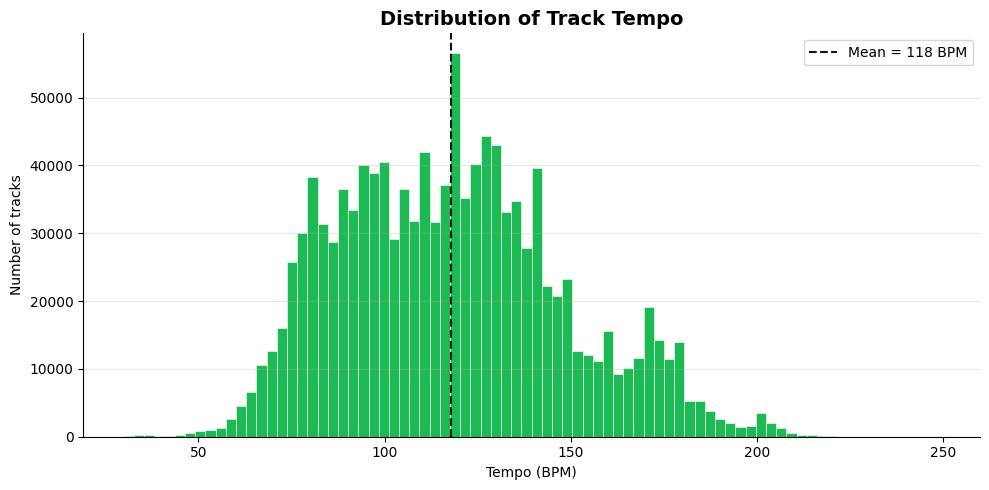

In [30]:
# Drop tempo == 0 (undetected/bad values that pile up at the far left)
tempo = df.loc[df["tempo"] > 0, "tempo"]
mean_tempo = tempo.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tempo, bins=80, color="#1DB954", edgecolor="white", linewidth=0.4)

# Mean reference line
ax.axvline(mean_tempo, color="#191414", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_tempo:.0f} BPM")

ax.set_title("Distribution of Track Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tempo (BPM)")
ax.set_ylabel("Number of tracks")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
df["duration_min"] = df["duration_ms"] / 60000

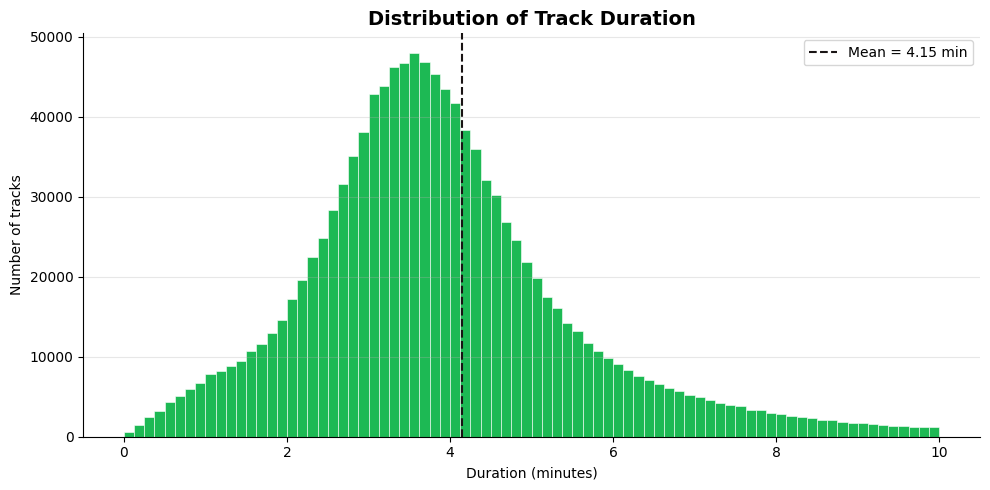

In [32]:
# graph for duration in minutes
# Keep real durations; clip the long tail (a few tracks run >10 min) so the
# bulk of the distribution stays readable
duration_min = df.loc[df["duration_min"] > 0, "duration_min"]
mean_min = duration_min.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(duration_min, bins=80, range=(0, 10),
        color="#1DB954", edgecolor="white", linewidth=0.4)

# Mean reference line
ax.axvline(mean_min, color="#191414", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_min:.2f} min")

ax.set_title("Distribution of Track Duration", fontsize=14, fontweight="bold")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of tracks")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

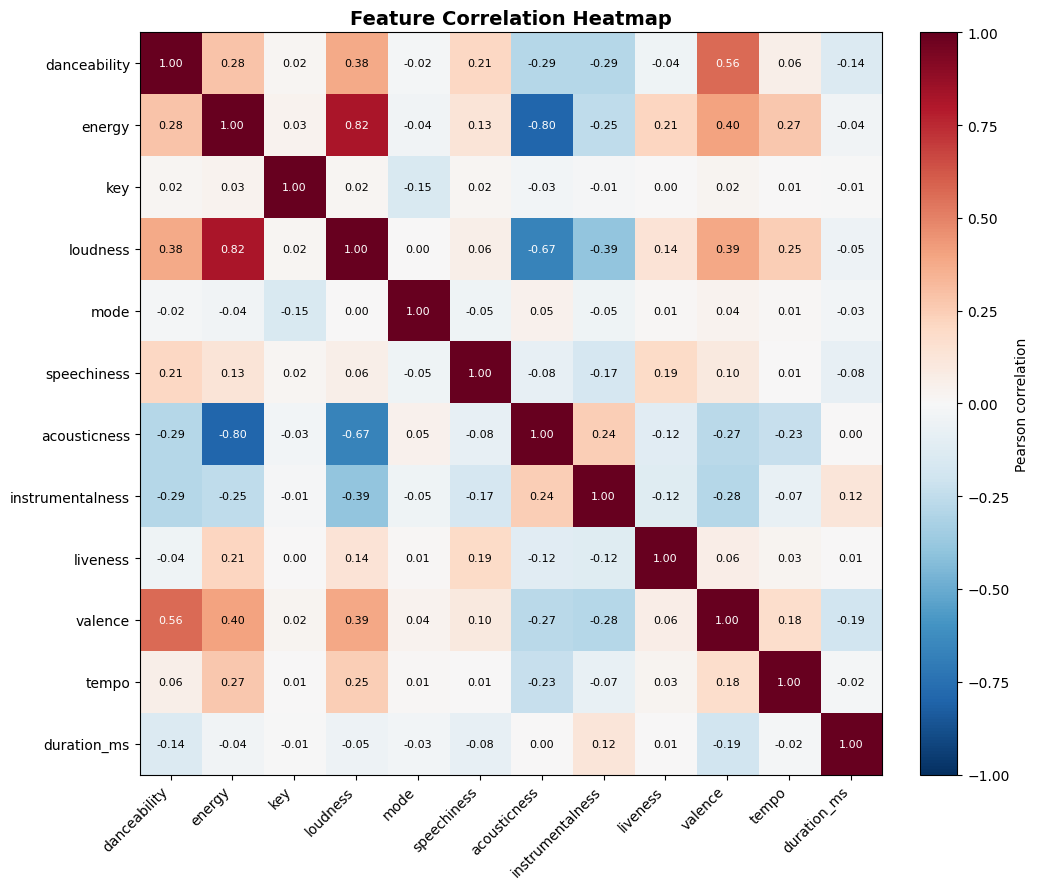

In [33]:
# correlation heatmap to choose good features
# Strongly correlated features are redundant for clustering; this helps spot them.
# (This dataset has no `popularity` column, so it is not included.)
heatmap_cols = ['danceability', 'energy', 'key', 'loudness', 'mode',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo', 'duration_ms']

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

# Ticks / labels
ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha="right")
ax.set_yticklabels(heatmap_cols)

# Annotate each cell with its correlation value
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=8)

ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.tight_layout()
plt.show()


In [34]:
# Feature selection for clustering.
# We keep the audio "character" features and drop `key` and `mode`:
# the heatmap above shows `key` has ~0 correlation with everything, and both are
# nominal/cyclical codes (0-11, 0/1) that only add noise to a Euclidean KMeans.
feature_columns = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness',
                   'valence', 'tempo']

# IMPORTANT: keep the full `df` intact (we need name/artists/year later to
# interpret the clusters). Build a separate feature matrix instead of overwriting df.
X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.12155906,  1.58971837,  0.91801582, ...,  0.85559864,
         0.27732985,  0.00878086],
       [ 0.5585726 ,  1.51845555,  0.86573955, ..., -0.25822719,
         0.22557085, -0.45105596],
       [-0.93877153,  1.56257063,  0.91443525, ..., -0.44109411,
        -0.21438062,  1.03806414],
       ...,
       [ 1.53922756,  0.97210732,  0.8376679 , ..., -0.74919718,
         0.14423529,  0.14098476],
       [ 0.90654694,  1.17571536,  0.71907953, ..., -0.46880122,
        -0.74306179,  0.23763259],
       [ 1.28088298,  0.67348219,  0.36231184, ...,  0.42890914,
        -0.82809443,  0.01152838]])

In [35]:
inertia_values = []

for k in range(1, 15):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

inertia_values

[10836197.99999995,
 7837906.877951,
 7014078.254855867,
 6390710.80778874,
 5760585.486011559,
 5234264.730774203,
 4916256.406558479,
 5054172.52712596,
 4497517.414838923,
 4295028.0785636455,
 4197201.968064142,
 4049723.160010917,
 3928697.1708431058,
 3709540.570438942]

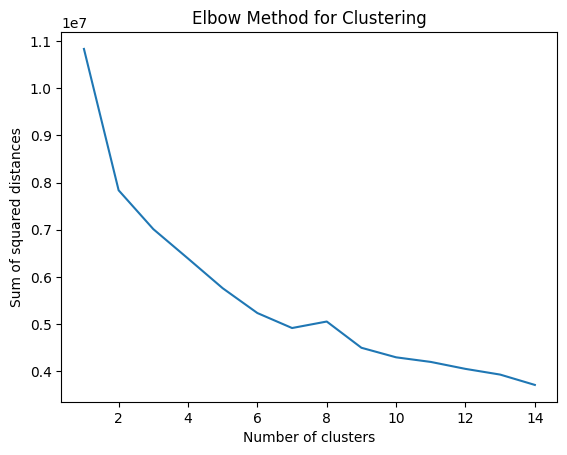

In [36]:
plt.plot(range(1, 15), inertia_values)
plt.title('Elbow Method for Clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distances')
plt.show()

In [37]:
optimal_k = 8
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_scaled)
clusters = cluster_labels                      # alias kept for older cells below
cluster_centers = kmeans_model.cluster_centers_

# Attach labels to the full dataframe so we can profile clusters by audio
# features AND by metadata (name, artists, year) further down.
df['Cluster'] = cluster_labels

df[['name', 'artists', 'year'] + feature_columns + ['Cluster']].head()

,name,artists,year,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,Testify,['Rage Against The Machine'],1999,0.470,0.978,-5.399,0.0727,0.02610,0.000011,0.3560,0.503,117.906,2
1,Guerrilla Radio,['Rage Against The Machine'],1999,0.599,0.957,-5.764,0.1880,0.01290,0.000071,0.1550,0.489,103.680,0
2,Calm Like a Bomb,['Rage Against The Machine'],1999,0.315,0.970,-5.424,0.4830,0.02340,0.000002,0.1220,0.370,149.749,3
3,Mic Check,['Rage Against The Machine'],1999,0.440,0.967,-5.830,0.2370,0.16300,0.000004,0.1210,0.574,96.752,2
4,Sleep Now In the Fire,['Rage Against The Machine'],1999,0.426,0.929,-6.729,0.0701,0.00162,0.105000,0.0789,0.539,127.059,2


In [38]:
# Silhouette score on a random sample (the full 114k is too slow for silhouette).
# Closer to 1 = well-separated clusters; near 0 = overlapping.
import numpy as np
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=10000, replace=False)
sil = silhouette_score(X_scaled[sample_idx], cluster_labels[sample_idx])
print(f"Silhouette score (k={optimal_k}, 10k sample): {sil:.3f}")

Silhouette score (k=8, 10k sample): 0.175


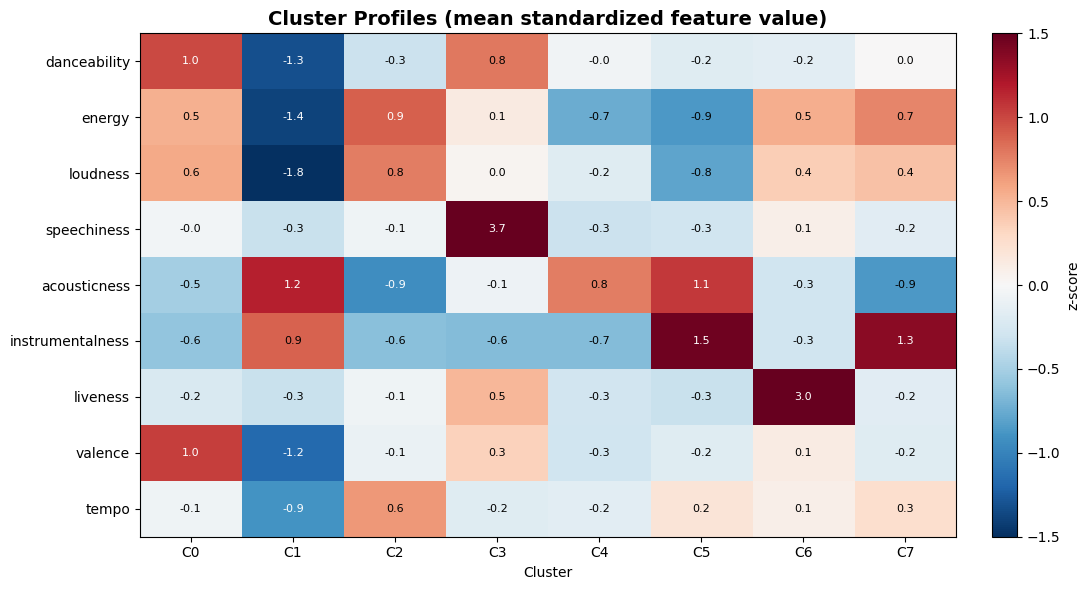

In [39]:
# Cluster profile: mean *standardized* value of each feature per cluster.
# Red = well above average for that feature, blue = well below. This is what
# makes each cluster "interesting" — it tells you the personality of each group.
profile = pd.DataFrame(X_scaled, columns=feature_columns)
profile['Cluster'] = cluster_labels
cluster_means = profile.groupby('Cluster').mean()

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(cluster_means.T, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')

ax.set_xticks(range(optimal_k))
ax.set_xticklabels([f'C{c}' for c in cluster_means.index])
ax.set_yticks(range(len(feature_columns)))
ax.set_yticklabels(feature_columns)

for i in range(len(feature_columns)):
    for j in range(optimal_k):
        val = cluster_means.iloc[j, i]
        ax.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.9 else 'black')

ax.set_title('Cluster Profiles (mean standardized feature value)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='z-score')
plt.tight_layout()
plt.show()

### Visualize the generated clusters

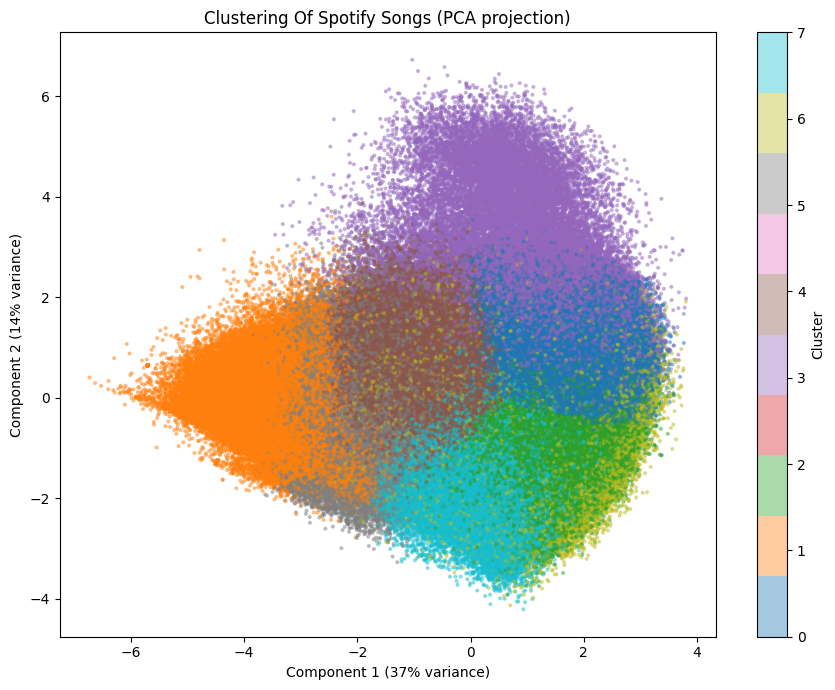

In [40]:
# PCA on the SCALED feature matrix (not the raw df, and NOT the Cluster column).
# This projects the 9 audio features down to 2D just for visualization.
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels,
                 cmap='tab10', s=4, alpha=0.4)
plt.title('Clustering Of Spotify Songs (PCA projection)')
plt.xlabel(f'Component 1 ({var[0]:.0f}% variance)')
plt.ylabel(f'Component 2 ({var[1]:.0f}% variance)')
plt.colorbar(sc, label='Cluster', ticks=range(optimal_k))
plt.tight_layout()
plt.show()

### Each cluster in its own graph

The combined scatter above gets crowded, so below we highlight one cluster at a
time (its points colored, the rest greyed out) using the same PCA projection.

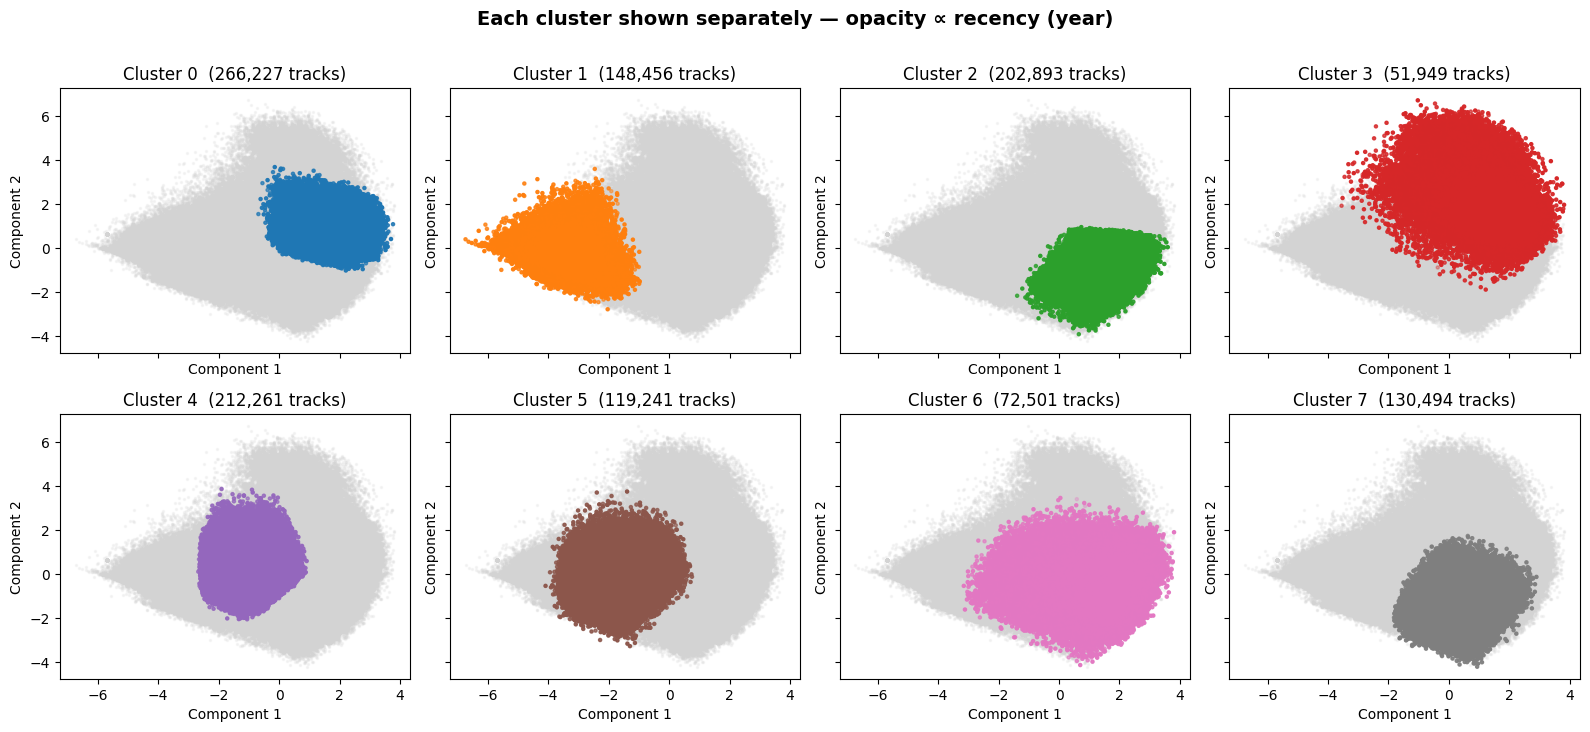

In [41]:
# One subplot per cluster on the shared PCA projection.
# This dataset has no popularity, so point opacity scales with *recency* instead:
# the newest releases show up solid, the oldest fade into the background.
ncols = 4
nrows = int(np.ceil(optimal_k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows),
                         sharex=True, sharey=True)
axes = axes.ravel()

# Map year -> alpha in [0.05, 1.0], using the valid (year > 0) range.
year = df['year'].to_numpy().astype(float)
valid = year[year > 0]
y_min, y_max = valid.min(), valid.max()
year_norm = np.clip((year - y_min) / (y_max - y_min), 0.0, 1.0)
point_alpha = 0.05 + 0.95 * year_norm

for c in range(optimal_k):
    ax = axes[c]
    # grey background = all other points (kept faint and uniform)
    ax.scatter(coords[:, 0], coords[:, 1], s=2, color='lightgray', alpha=0.2)

    mask = cluster_labels == c
    # bake per-point alpha into RGBA so each dot fades by its own recency,
    # then draw newest last so they sit on top
    order = np.argsort(point_alpha[mask])
    idx = np.flatnonzero(mask)[order]
    rgba = np.tile(plt.cm.tab10(c % 10), (idx.size, 1))
    rgba[:, 3] = point_alpha[idx]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=5, color=rgba)

    ax.set_title(f'Cluster {c}  ({mask.sum():,} tracks)')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

# hide any unused axes
for j in range(optimal_k, len(axes)):
    axes[j].axis('off')

fig.suptitle('Each cluster shown separately — opacity ∝ recency (year)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

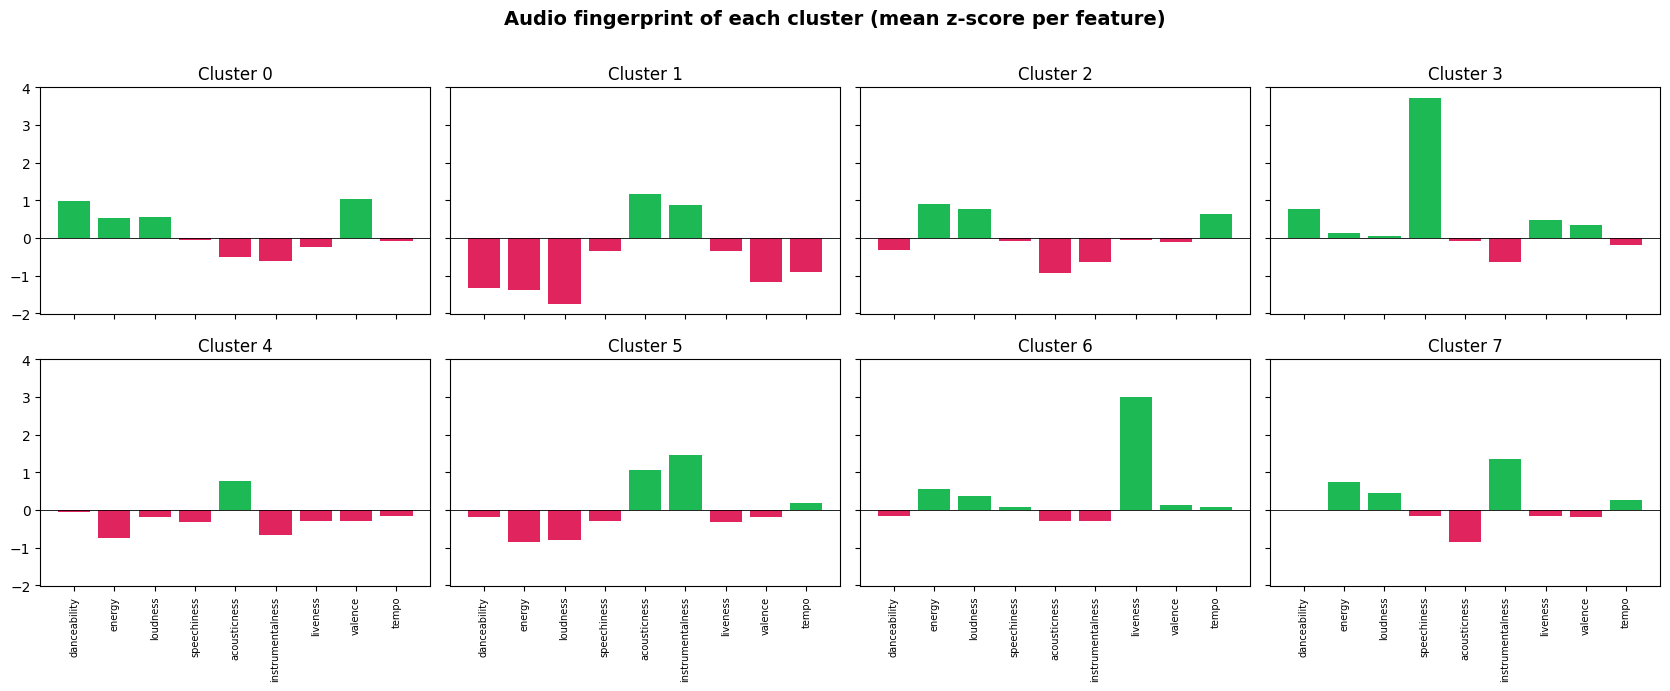

In [42]:
# Each cluster's audio "fingerprint" in its own bar chart (mean standardized
# feature values). Bars above 0 = above the dataset average, below 0 = under it.
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                         sharex=True, sharey=True)
axes = axes.ravel()

for c in range(optimal_k):
    ax = axes[c]
    vals = cluster_means.loc[c]
    colors = ['#1DB954' if v >= 0 else '#E0245E' for v in vals]
    ax.bar(range(len(feature_columns)), vals, color=colors)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'Cluster {c}')
    ax.set_xticks(range(len(feature_columns)))
    ax.set_xticklabels(feature_columns, rotation=90, fontsize=7)

for j in range(optimal_k, len(axes)):
    axes[j].axis('off')

fig.suptitle('Audio fingerprint of each cluster (mean z-score per feature)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [43]:
# Interpret the clusters: size, the 2 most extreme audio traits, the typical
# release era, and the most common artists in each. This dataset has no genre
# column, so top artists stand in for "what kind of music is this".
summary = []
for c in range(optimal_k):
    m = cluster_means.loc[c]
    hi = m.sort_values(ascending=False).head(2).index.tolist()   # strongest traits
    lo = m.sort_values().head(2).index.tolist()                  # weakest traits
    sub = df.loc[df['Cluster'] == c]
    top_artists = sub['artists'].value_counts().head(3).index.tolist()
    median_year = int(sub.loc[sub['year'] > 0, 'year'].median())
    summary.append({
        'Cluster': c,
        'Size': int((cluster_labels == c).sum()),
        'High in': ', '.join(hi),
        'Low in': ', '.join(lo),
        'Median year': median_year,
        'Top artists': ', '.join(a.strip("[]'") for a in top_artists),
    })

summary_df = pd.DataFrame(summary).set_index('Cluster')
summary_df

,Size,High in,Low in,Median year,Top artists
Cluster,,,,,
0,266227,"valence, danceability","instrumentalness, acousticness",2009,"Aretha Franklin, Cumbia Latin Band, Die Flippers"
1,148456,"acousticness, instrumentalness","loudness, energy",2007,"""Dan Gibson's Solitudes"", The City of Prague P..."
2,202893,"energy, loudness","acousticness, instrumentalness",2011,"The Fall, Grant Macdonald, Guided By Voices"
3,51949,"speechiness, danceability","instrumentalness, tempo",2011,"Noam Chomsky, TKKG, Howard Zinn"
4,212261,"acousticness, danceability","energy, instrumentalness",2007,"Aretha Franklin, Vitamin String Quartet, Dionn..."
5,119241,"instrumentalness, acousticness","energy, loudness",2007,"Vitamin String Quartet, Rockabye Baby!, Variou..."
6,72501,"liveness, energy","instrumentalness, acousticness",2008,"Tori Amos, Bob Dylan, Udo Jürgens"
7,130494,"instrumentalness, energy","acousticness, valence",2011,"Revolt Production Music, Epic Score, Songs To ..."


In [44]:
# This dataset has no `popularity` column, so we can't rank tracks by plays.
# Instead we surface each cluster's *archetypes*: the tracks sitting closest to
# their cluster centroid in the scaled feature space. These are the songs that
# most typify what the cluster "sounds like".
#
# The same recording can appear more than once (e.g. on a single and an album),
# so collapse to one row per (name, artists) first.

# Distance from every track to its own cluster centroid (Euclidean, scaled space).
dist_to_centers = kmeans_model.transform(X_scaled)
own_dist = dist_to_centers[np.arange(len(cluster_labels)), cluster_labels]

ranked = df.copy()
ranked['centroid_dist'] = own_dist

deduped = (
    ranked.sort_values('centroid_dist', ascending=True)
          .drop_duplicates(subset=['name', 'artists'], keep='first')
)

# Closest 5 tracks to the centroid within each cluster.
archetypes = (
    deduped
      .groupby('Cluster', group_keys=False)
      .head(5)
      .sort_values(['Cluster', 'centroid_dist'], ascending=[True, True])
      .copy()
)

archetypes['Rank'] = archetypes.groupby('Cluster').cumcount() + 1

arch_table = archetypes.set_index(['Cluster', 'Rank'])[
    ['name', 'artists', 'year', 'centroid_dist']
].round({'centroid_dist': 3})

# Show the whole thing (all clusters) without pandas truncating.
with pd.option_context('display.max_rows', None):
    display(arch_table)

name  \
Cluster Rank                                                      
0       1                                        Child Forgiven   
        2                                      It Is What It Is   
        3                                        Chocolate Drop   
        4                                                Credit   
        5                                   Close the Barn Door   
1       1     String Quartet No. 3 in E Minor, Op. 136: III....   
        2     Violin Concerto No. 3 in B Minor, Op. 61: III....   
        3             Variations On Luchinushka By G. Rachinsky   
        4            Cockney Suite: III. At the Palais de Danse   
        5     Violin Concerto No. 2, BB 117: III. Allegro molto   
2       1                                                    TV   
        2                                                Undone   
        3                                                  Only   
        4                                            Cybernesis   
        5                                            Now I Know   
3       1                                 We Are One - Acapella   
        2                                   Conversation, Pt. 1   
        3                                             Don't Cry   
        4                        Its About Love Based Freestyle   
        5                                            Feels Good   
4       1                                      Two Funky People   
        2                                   Pour que tu m'aimes   
        3                                           Katie Cruel   
        4                                    Summertime Sadness   
        5                                            Si Volvera   
5       1                           La scala di seta: Ouverture   
        2     Symphony No. 3 in E-Flat Major, Op. 97 "Rhenis...   
        3                                     Out of This World   
        4     String Quartet No. 3, Sz. 85: Seconda parte: A...   
        5                                    Satellite Luminary   
6       1                                Nine Below Zero - Live   
        2                                        Happiness Ball   
        3                                     2 Song Set (Live)   
        4                                    Dance Mediterrania   
        5                                      Shroud of Flames   
7       1                                                 Stuck   
        2                                            Milestones   
        3                                                  Wish   
        4                                         The Institute   
        5                               Sleeping With Asclepius   

                                                        artists  year  \
Cluster Rank                                                            
0       1                                  ['Heritage Singers']  2008   
        2                     ['Chaotic Queen', 'Marcus Money']  2020   
        3                   ['The Mannish Boys', 'Bobby Jones']  2008   
        4                                    ['Meghan Trainor']  2015   
        5                                     ['49th Parallel']  1969   
1       1           ['Joachim Raff', 'Mannheim String Quartet']  2015   
        2     ['Camille Saint-Saëns', 'Dong-Suk Kang', 'Poli...  1994   
        3          ['Talisman', 'Kolpakov Trio', 'Traditional']  2005   
        4     ['Albert Ketèlbey', 'Slovak Radio Symphony Orc...  1993   
        5     ['Béla Bartók', 'György Pauk', 'Polish Nationa...  1999   
2       1                                               ['LAB']  2002   
        2                                           ['Noctura']  2011   
        3                                        ['Ben Alessi']  2017   
        4                                        ['Illidiance']  2009   
        5                                ['Shattered On Stone']  2013   
3  